In [31]:
import torch
import torch.nn as nn
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset,DataLoader
from sklearn.metrics import accuracy_score
import torch.optim as optim

In [32]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [33]:
df=pd.read_csv("fashion-mnist_train.csv")
x=df.drop(columns=['label'])/255.0
y=df['label']
print(len(x))

60000


In [34]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8)
print(len(x_train))

48000


In [35]:
class customDataset(Dataset):
  def __init__(self,batch_features,batch_labels):
    self.batch_features=batch_features.reshape(-1,1,28,28)
    self.batch_labels=batch_labels
  def __len__(self):
    return len(self.batch_features)
  def __getitem__(self,idx):
    return self.batch_features[idx],self.batch_labels[idx]

In [36]:
x_train=torch.tensor(x_train.values,dtype=torch.float32)
y_train=torch.tensor(y_train.values,dtype=torch.long)
x_test=torch.tensor(x_test.values,dtype=torch.float32)
y_test=torch.tensor(y_test.values,dtype=torch.long)
train_dataset=customDataset(x_train,y_train)
test_dataset=customDataset(x_test,y_test)

In [37]:
train_loader=DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)
test_loader=DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=True
)

In [38]:
class MyNN(nn.Module):
  def __init__(self,input_features):
    super().__init__()
    self.features=nn.Sequential(
        nn.Conv2d(input_features,32,kernel_size=3,padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2,stride=2),
        nn.Conv2d(32,64,kernel_size=3,padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )
    self.classifier=nn.Sequential(
        nn.Flatten(),
        nn.Linear(7*7*64,128),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(64,10)
    )
  def forward(self,x):
    x=self.features(x)
    x=self.classifier(x)
    return x

In [39]:
model=MyNN(1).to(device)

In [40]:
num_epochs=10
learning_rate=0.001
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate,weight_decay=1e-4)
model.train()

MyNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [41]:
for epoch in range(num_epochs):
  for batch_features,batch_labels in train_loader:
    batch_features=batch_features.to(device)
    batch_labels=batch_labels.to(device)
    optimizer.zero_grad()
    output=model(batch_features)
    loss=loss_fn(output,batch_labels)
    loss.backward()
    optimizer.step()
  print(f"After Epoch: {epoch+1}, Loss: {loss.item():.4f}")

After Epoch: 1, Loss: 1.1624
After Epoch: 2, Loss: 0.7882
After Epoch: 3, Loss: 0.6345
After Epoch: 4, Loss: 0.7153
After Epoch: 5, Loss: 0.6056
After Epoch: 6, Loss: 0.4762
After Epoch: 7, Loss: 0.4674
After Epoch: 8, Loss: 0.4250
After Epoch: 9, Loss: 0.4820
After Epoch: 10, Loss: 0.4521


In [42]:
correct=0
total=0
model.eval()
with torch.no_grad():
  for batch_features,batch_labels in test_loader:
    batch_features=batch_features.to(device)
    batch_labels=batch_labels.to(device)
    output=model(batch_features)
    pred=torch.argmax(output,dim=1)
    total+=batch_features.shape[0]
    correct+=(pred==batch_labels).sum().item()
  print("Testing Accuracy:",correct/total)


Testing Accuracy: 0.8640833333333333


In [43]:
correct=0
total=0
model.eval()
with torch.no_grad():
  for batch_features,batch_labels in train_loader:
    batch_features=batch_features.to(device)
    batch_labels=batch_labels.to(device)
    output=model(batch_features)
    pred=torch.argmax(output,dim=1)
    total+=batch_features.shape[0]
    correct+=(pred==batch_labels).sum().item()
  print("Training Accuracy:",correct/total)


Training Accuracy: 0.8684166666666666


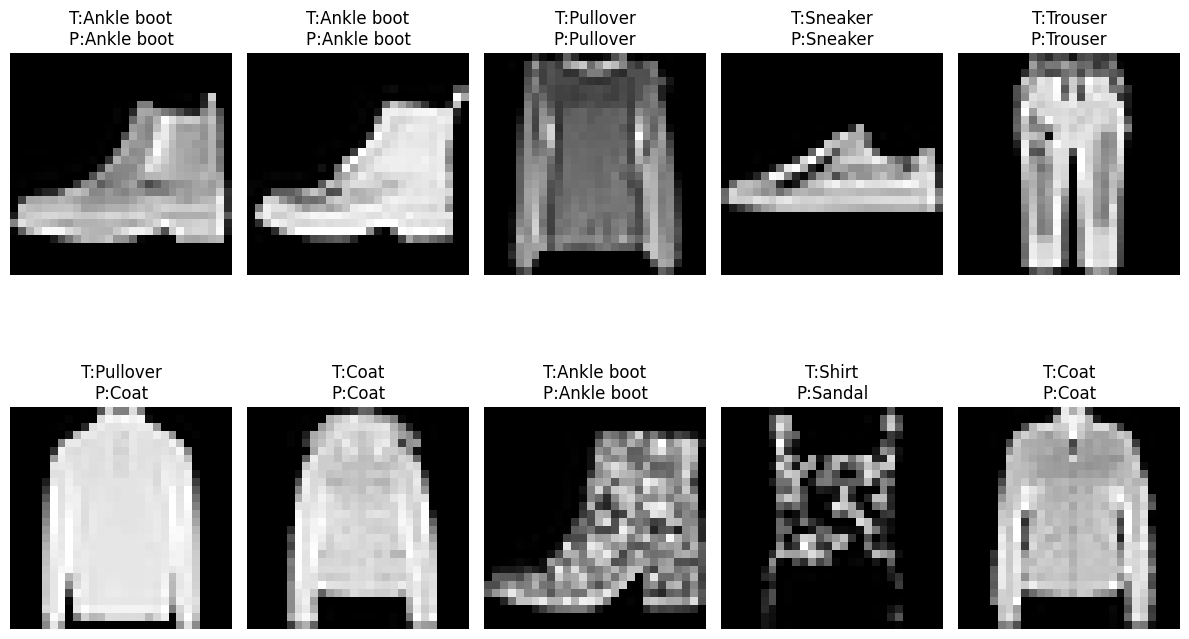

In [44]:
import matplotlib.pyplot as plt
import torch

classes = [
    "T-shirt", "Trouser", "Pullover", "Dress",
    "Coat", "Sandal", "Shirt", "Sneaker",
    "Bag", "Ankle boot"
]

model.eval()

with torch.no_grad():

    batch_features, batch_labels = next(iter(test_loader))

    batch_features = batch_features.to(device)

    output = model(batch_features)

    pred = torch.argmax(output, dim=1)

    plt.figure(figsize=(12,8))

    for i in range(10):

        plt.subplot(2,5,i+1)

        plt.imshow(
            batch_features[i].cpu().reshape(28,28),
            cmap="gray"
        )

        plt.title(
            f"T:{classes[batch_labels[i]]}\n"
            f"P:{classes[pred[i].cpu()]}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [45]:
!pip install optuna

In [46]:
import optuna
print(optuna.__version__)

4.8.0


In [47]:
class MyNN(nn.Module):
  def __init__(self,input_features,n_con_layers,n_layers,kernel_size,neurons_per_layer,dropout):
    super().__init__()
    layers=[]
    out_features=32
    for i in range(n_con_layers):
      layers.append(nn.Conv2d(input_features,out_features,kernel_size=kernel_size,padding='same'))
      layers.append(nn.BatchNorm2d(out_features))
      layers.append(nn.ReLU())
      layers.append(nn.MaxPool2d(kernel_size=2,stride=2))
      input_features=out_features
      out_features=64
    layers.append(nn.Flatten())
    size = 28 // (2**n_con_layers)
    ip = size * size * input_features
    for i in range(n_layers):
      layers.append(nn.Linear(ip,neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout))
      ip=neurons_per_layer
    layers.append(nn.Linear(neurons_per_layer,10))
    self.model=nn.Sequential(*layers)
  def forward(self,x):
    return self.model(x)

In [52]:
def objective(trail):
  n_con_layers=trail.suggest_int("n_con_layers",1,2)
  kernel_size=trail.suggest_int("kernel_size",3,5)
  n_layers=trail.suggest_int("n_layers",1,5)
  neurons_per_layer=trail.suggest_int("neurons_per_layer",8,144,step=8)
  epochs=trail.suggest_int("epochs",10,100,step=10)
  learning_rate=trail.suggest_float("learning_rate",1e-5,1e-1,log=True)
  weight_decay=trail.suggest_float("weight_decay",1e-5,1e-3,log=True)
  dropout_rate=trail.suggest_float("dropout_rate",0.1,0.5,step=0.1)
  optimizer_name=trail.suggest_categorical("optimizer_name",["Adam","SGD",'RMSprop'])
  batch_size=trail.suggest_categorical("batch_size",[64,128,256])
  train_loader=DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
  )
  test_loader=DataLoader(
      test_dataset,
      batch_size=batch_size,
      shuffle=True
  )
  model=MyNN(1,n_con_layers,n_layers,kernel_size,neurons_per_layer,dropout_rate)
  model.to(device)
  loss_fn=nn.CrossEntropyLoss()
  if optimizer_name=='Adam':
    optimizer=optim.Adam(model.parameters(),lr=learning_rate,weight_decay=weight_decay)
  elif optimizer_name=='SGD':
    optimizer=optim.SGD(model.parameters(),lr=learning_rate,weight_decay=weight_decay)
  else:
    optimizer=optim.RMSprop(model.parameters(),lr=learning_rate,weight_decay=weight_decay)
  model.train()
  for epoch in range(epochs):
    for batch_features,batch_labels in train_loader:
      optimizer.zero_grad()
      batch_features=batch_features.to(device)
      batch_labels=batch_labels.to(device)
      output=model(batch_features)
      loss=loss_fn(output,batch_labels)
      loss.backward()
      optimizer.step()
  model.eval()
  total=0
  correct=0
  with torch.no_grad():
    for batch_features,batch_labels in test_loader:
      batch_features=batch_features.to(device)
      batch_labels=batch_labels.to(device)
      outputs=model(batch_features)
      outputs=torch.argmax(outputs,dim=1)
      total+=batch_labels.shape[0]
      correct+=(outputs==batch_labels).sum().item()
  accuracy=correct/total
  return accuracy

In [54]:
study=optuna.create_study(direction="maximize")
study.optimize(objective,n_trials=30)


[I 2026-05-25 14:48:15,984] A new study created in memory with name: no-name-5d5a069a-b606-4e2b-acfb-92560d0145f9
[I 2026-05-25 14:50:46,301] Trial 0 finished with value: 0.84975 and parameters: {'n_con_layers': 1, 'kernel_size': 3, 'n_layers': 1, 'neurons_per_layer': 8, 'epochs': 80, 'learning_rate': 0.007768381141762918, 'weight_decay': 1.1684905874318971e-05, 'dropout_rate': 0.5, 'optimizer_name': 'Adam', 'batch_size': 128}. Best is trial 0 with value: 0.84975.
[I 2026-05-25 14:51:52,765] Trial 1 finished with value: 0.34641666666666665 and parameters: {'n_con_layers': 2, 'kernel_size': 3, 'n_layers': 3, 'neurons_per_layer': 128, 'epochs': 30, 'learning_rate': 2.2517739183788294e-05, 'weight_decay': 9.92038362665573e-05, 'dropout_rate': 0.1, 'optimizer_name': 'SGD', 'batch_size': 128}. Best is trial 0 with value: 0.84975.
[I 2026-05-25 14:52:52,894] Trial 2 finished with value: 0.8371666666666666 and parameters: {'n_con_layers': 1, 'kernel_size': 4, 'n_layers': 3, 'neurons_per_layer

In [55]:
study.best_params

{'n_con_layers': 2,
 'kernel_size': 5,
 'n_layers': 4,
 'neurons_per_layer': 144,
 'epochs': 60,
 'learning_rate': 0.0014180163623930167,
 'weight_decay': 1.2339595718374757e-05,
 'dropout_rate': 0.4,
 'optimizer_name': 'Adam',
 'batch_size': 256}

In [56]:
study.best_value

0.9206666666666666

In [59]:
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_slice,
    plot_contour,
    plot_edf,
    plot_intermediate_values
)
from optuna.visualization import plot_timeline

In [61]:
plot_optimization_history(study).show()
plot_param_importances(study).show()

In [64]:
plot_parallel_coordinate(study)

In [65]:

plot_slice(study)
